# LIANA+ predicted interactions: SPC25-high/low malignant cells and immune target populations

This notebook divides curated malignant epithelial cells into `SPC25-high malignant` and `SPC25-low malignant`, compares malignant-cell ligand expression, and runs LIANA+ ligand-receptor inference against macrophage, monocyte, T cell, NK cell, and DC populations.

Use wording such as **predicted interactions** or **communication patterns** when describing these results. Do not present them as causal mechanisms without orthogonal validation.

Outputs are written to `results/liana_spc25/`.

In [1]:
from pathlib import Path
import json
import re
import sys
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

import liana as li

warnings.filterwarnings('ignore')

BASE_DIR = Path('/data/work/2026317luad')
OUT_DIR = BASE_DIR / 'results' / 'liana_spc25'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FULL_H5AD = BASE_DIR / 'GSE131907_GSE253013_allgenes_cnv.h5ad'
MALIGNANT_H5AD = BASE_DIR / 'GSE131907_GSE253013_mEpi_anno.h5ad'
GENE = 'SPC25'
CELLTYPE_COL = 'Cell_type'
SUBTYPE_COL = 'Cell_subtype'
GROUP_COL = 'liana_group'
SEED = 2024

# Set to None for full data. Keeping a cap makes exploratory runs much faster.
MAX_CELLS_PER_GROUP = 15000

# LIANA parameters. For final analysis, keep N_PERMS=1000 if runtime allows.
EXPR_PROP = 0.10
MIN_CELLS = 20
N_PERMS = 1000
N_JOBS = 12

print('LIANA:', li.__version__)
print('Output:', OUT_DIR)

LIANA: 1.7.3
Output: /data/work/2026317luad/results/liana_spc25


## Select curated malignant cells plus immune populations

In [2]:
def normalize_text(x):
    if pd.isna(x):
        return ''
    return str(x)


def immune_label(row):
    ct = normalize_text(row.get(CELLTYPE_COL, ''))
    sub = normalize_text(row.get(SUBTYPE_COL, ''))
    both = f'{ct} {sub}'.lower()
    if 'macrophage' in both or 'mac' in both:
        return 'Macrophage'
    if 'monocyte' in both or 'monocytes' in both:
        return 'Monocyte'
    if 'nk cell' in both or both.strip() == 'nk' or ' nk' in both:
        return 'NK cell'
    if 't cell' in both or 't cells' in both or 'cd4' in both or 'cd8' in both or 'treg' in both:
        return 'T cell'
    if re.search(r'\bdc\b', both) or 'dendritic' in both or 'plasmacytoid dc' in both or 'cd1c+ dcs' in both:
        return 'DC'
    return None

mal_b = sc.read_h5ad(MALIGNANT_H5AD, backed='r')
curated_malignant_ids = pd.Index(mal_b.obs_names)
mal_b.file.close()

full_b = sc.read_h5ad(FULL_H5AD, backed='r')
obs = full_b.obs.copy()
obs['immune_liana_label'] = obs.apply(immune_label, axis=1)
obs['is_curated_malignant'] = obs.index.isin(curated_malignant_ids)

rng = np.random.default_rng(SEED)
selected_ids = list(obs.index[obs['is_curated_malignant']])
immune_summary = []
for label in ['Macrophage', 'Monocyte', 'T cell', 'NK cell', 'DC']:
    # Critical: do not let broad full-object labels overwrite the curated malignant set.
    pool = obs.index[obs['immune_liana_label'].eq(label) & ~obs['is_curated_malignant']].to_numpy()
    n_total = len(pool)
    if MAX_CELLS_PER_GROUP is not None and n_total > MAX_CELLS_PER_GROUP:
        pool = rng.choice(pool, size=MAX_CELLS_PER_GROUP, replace=False)
    selected_ids.extend(pool.tolist())
    immune_summary.append({'immune_group': label, 'n_total_nonmalignant': n_total, 'n_selected': len(pool)})

selected_ids = pd.Index(pd.unique(selected_ids))
pd.DataFrame(immune_summary).to_csv(OUT_DIR / 'immune_cells_selected_for_liana.csv', index=False)

print('Selected cells to load:', len(selected_ids))
print('Curated malignant:', int(obs.loc[selected_ids, 'is_curated_malignant'].sum()))
print(pd.DataFrame(immune_summary))

adata = full_b[selected_ids, :].to_memory()
full_b.file.close()
adata.obs['immune_liana_label'] = obs.loc[adata.obs_names, 'immune_liana_label'].values
adata.obs['is_curated_malignant'] = obs.loc[adata.obs_names, 'is_curated_malignant'].values
adata

Selected cells to load: 76950
Curated malignant: 21548
  immune_group  n_total_nonmalignant  n_selected
0   Macrophage                 56912       15000
1     Monocyte                 10398       10398
2       T cell                125492       15000
3      NK cell                 34124       15000
4           DC                     4           4


AnnData object with n_obs × n_vars = 76950 × 25089
    obs: 'Barcode', 'Sample', 'Sample_Origin', 'Cell_type', 'Cell_type.refined', 'Cell_subtype', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'library_id', 'SampleGroup', 'tissue_type', 'PatientID', 'Age', 'Sex', 'Site', 'AJCC_TNM_8th_Edition', 'AJCC_Stage_8th_Edition', 'Histology', 'Ethnicity', 'SmokingStatus', 'PriorTreatment', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'cell_type', 'dataset', 'predicted_doublets_log', 'scrublet_score_log', 'predicted_doublets_z', 'scrublet_score_z', 'predicted_doublets_default', 'scrublet_score_default', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_01', 'leiden_02', 'leiden_03', 'leiden_04', 'cnv_leiden', 'cnv_score', 'dataset_hint', 'Group2', 'Group_simple', 'cnv_status', 'immune_liana_label', 'is_curated_malignant'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_drop

## Normalize expression and define SPC25-high / SPC25-low malignant groups

`GSE131907_GSE253013_allgenes_cnv.h5ad` stores raw count-like values, so this notebook keeps counts in `layers['counts']`, then uses CPM-like normalization plus log1p for expression comparisons and LIANA.

In [3]:
if GENE not in adata.var_names:
    raise ValueError(f'{GENE} is not present in adata.var_names')

adata.layers['counts'] = adata.X.copy()

# Define SPC25 high/low from raw counts first. In this dataset SPC25 is sparse;
# if the median and upper quartile are both zero, use SPC25-positive vs zero.
malignant_mask = adata.obs['is_curated_malignant'].to_numpy(dtype=bool)
gene_idx = adata.var_names.get_loc(GENE)
raw_spc25 = adata.layers['counts'][malignant_mask, gene_idx]
if sparse.issparse(raw_spc25):
    raw_spc25 = raw_spc25.toarray()
raw_spc25 = np.asarray(raw_spc25).ravel()

quantiles = {str(q): float(np.quantile(raw_spc25, q)) for q in [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]}
nonzero_n = int((raw_spc25 > 0).sum())
nonzero_pct = float((raw_spc25 > 0).mean())

if quantiles['0.5'] <= 0 and quantiles['0.75'] <= 0:
    group_rule = 'SPC25-positive raw count (>0) versus SPC25-zero raw count (=0) because median and Q3 are zero'
    high_mask_mal = raw_spc25 > 0
    threshold = 0.0
else:
    group_rule = 'Median split on raw SPC25 counts among curated malignant cells'
    threshold = quantiles['0.5']
    high_mask_mal = raw_spc25 >= threshold

spc25_distribution = pd.DataFrame({
    'metric': ['n_malignant', 'n_spc25_positive', 'pct_spc25_positive'] + [f'q{q}' for q in quantiles.keys()],
    'value': [int(raw_spc25.size), nonzero_n, nonzero_pct] + list(quantiles.values()),
})
spc25_distribution.to_csv(OUT_DIR / 'spc25_raw_count_distribution_curated_malignant.csv', index=False)
(OUT_DIR / 'spc25_group_definition.json').write_text(json.dumps({
    'gene': GENE,
    'group_rule': group_rule,
    'threshold': threshold,
    'quantiles': quantiles,
    'n_malignant': int(raw_spc25.size),
    'n_spc25_positive': nonzero_n,
    'pct_spc25_positive': nonzero_pct,
}, indent=2), encoding='utf-8')

# Normalize after group definition; LIANA and ligand-expression summaries use log1p-normalized expression.
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

malignant_ids = adata.obs_names[malignant_mask]
high_ids = pd.Index(malignant_ids[high_mask_mal])
low_ids = pd.Index(malignant_ids[~high_mask_mal])
nonmalignant_immune_mask = (~malignant_mask) & adata.obs['immune_liana_label'].notna().to_numpy()

adata.obs[GROUP_COL] = pd.Series(index=adata.obs_names, dtype='object')
adata.obs.loc[high_ids, GROUP_COL] = 'SPC25-high malignant'
adata.obs.loc[low_ids, GROUP_COL] = 'SPC25-low malignant'
adata.obs.loc[nonmalignant_immune_mask, GROUP_COL] = adata.obs.loc[nonmalignant_immune_mask, 'immune_liana_label']
adata = adata[adata.obs[GROUP_COL].notna()].copy()
adata.obs[GROUP_COL] = adata.obs[GROUP_COL].astype('category')

counts = adata.obs[GROUP_COL].value_counts().rename('n_cells').reset_index()
counts.columns = [GROUP_COL, 'n_cells']
counts.to_csv(OUT_DIR / 'spc25_liana_group_cell_counts_before_post_group_downsampling.csv', index=False)
print(group_rule)
print('SPC25 raw-count distribution:', quantiles)
counts

SPC25-positive raw count (>0) versus SPC25-zero raw count (=0) because median and Q3 are zero
SPC25 raw-count distribution: {'0': 0.0, '0.25': 0.0, '0.5': 0.0, '0.75': 0.0, '0.9': 0.0, '0.95': 0.0, '0.99': 1.0, '1.0': 21.0}


,liana_group,n_cells
0,SPC25-low malignant,21182
1,NK cell,15000
2,Macrophage,15000
3,T cell,15000
4,Monocyte,10398
5,SPC25-high malignant,366
6,DC,4


## Optional downsampling for exploratory LIANA runs

The code preserves all groups and caps each group at `MAX_CELLS_PER_GROUP`. Set `MAX_CELLS_PER_GROUP = None` above for a full run.

In [4]:
if MAX_CELLS_PER_GROUP is not None:
    rng = np.random.default_rng(SEED)
    keep_pos = []
    for group, positions in adata.obs.groupby(GROUP_COL, observed=True).indices.items():
        positions = np.asarray(positions)
        if len(positions) > MAX_CELLS_PER_GROUP:
            positions = rng.choice(positions, size=MAX_CELLS_PER_GROUP, replace=False)
        keep_pos.extend(positions.tolist())
    keep_pos = np.array(sorted(keep_pos))
    adata = adata[keep_pos].copy()

adata.obs[GROUP_COL].value_counts()

liana_group
Macrophage              15000
SPC25-low malignant     15000
NK cell                 15000
T cell                  15000
Monocyte                10398
SPC25-high malignant      366
DC                          4
Name: count, dtype: int64

## Compare ligand expression between SPC25-high and SPC25-low malignant cells

In [5]:
def get_liana_resource(name='consensus'):
    # Supports both recent and older LIANA namespaces.
    if hasattr(li, 'resource') and hasattr(li.resource, 'select_resource'):
        return li.resource.select_resource(name)
    if hasattr(li, 'rs') and hasattr(li.rs, 'select_resource'):
        return li.rs.select_resource(name)
    raise AttributeError('Could not find LIANA resource selector.')


def split_complex(x):
    return [g for g in re.split(r'[_&|]+', str(x)) if g and g != 'nan']

resource = get_liana_resource('consensus')
ligand_col = 'ligand' if 'ligand' in resource.columns else 'ligand_complex'
all_ligands = sorted({g for item in resource[ligand_col].dropna().astype(str) for g in split_complex(item)})
ligands = [g for g in all_ligands if g in adata.var_names]
print('LIANA consensus ligand genes in dataset:', len(ligands))

mal = adata[adata.obs[GROUP_COL].isin(['SPC25-high malignant', 'SPC25-low malignant']), ligands].copy()
rows = []
for group in ['SPC25-high malignant', 'SPC25-low malignant']:
    sub = mal[mal.obs[GROUP_COL] == group]
    X = sub.X
    if sparse.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        pct = np.asarray((X > 0).mean(axis=0)).ravel()
    else:
        mean = X.mean(axis=0)
        pct = (X > 0).mean(axis=0)
    rows.append(pd.DataFrame({'gene': ligands, 'group': group, 'mean_log1p': mean, 'pct_expr': pct}))
expr = pd.concat(rows, ignore_index=True)
wide = expr.pivot(index='gene', columns='group', values=['mean_log1p', 'pct_expr'])
wide.columns = [f'{a}_{b}' for a, b in wide.columns]
wide = wide.reset_index()
wide['delta_mean_log1p_high_minus_low'] = wide['mean_log1p_SPC25-high malignant'] - wide['mean_log1p_SPC25-low malignant']
wide['delta_pct_expr_high_minus_low'] = wide['pct_expr_SPC25-high malignant'] - wide['pct_expr_SPC25-low malignant']
wide = wide.sort_values('delta_mean_log1p_high_minus_low', ascending=False)
wide.to_csv(OUT_DIR / 'spc25_high_vs_low_ligand_expression.csv', index=False)
wide.head(30)

LIANA consensus ligand genes in dataset: 938


,gene,mean_log1p_SPC25-high malignant,mean_log1p_SPC25-low malignant,pct_expr_SPC25-high malignant,pct_expr_SPC25-low malignant,delta_mean_log1p_high_minus_low,delta_pct_expr_high_minus_low
935,YBX1,2.144698,1.268441,0.967213,0.828400,0.876257,0.138813
429,HMGB1,2.453872,1.684769,0.991803,0.939667,0.769104,0.052137
581,MDK,2.096366,1.402778,0.939891,0.781333,0.693589,0.158557
751,S100A10,3.167878,2.478082,0.991803,0.942267,0.689796,0.049537
52,APOE,0.793872,0.168515,0.497268,0.154267,0.625357,0.343001
664,PCNA,0.757481,0.211428,0.707650,0.277733,0.546053,0.429917
744,RPS19,4.112988,3.578680,1.000000,0.998667,0.534308,0.001333
40,ANXA1,2.010934,1.508650,0.934426,0.823533,0.502284,0.110893
168,CKLF,1.028109,0.541769,0.844262,0.552200,0.486340,0.292062
591,MIF,1.287417,0.802117,0.918033,0.634133,0.485299,0.283899


## Run LIANA+ rank aggregate for selected source-target pairs

In [6]:
malignant_groups = ['SPC25-high malignant', 'SPC25-low malignant']
immune_groups = ['Macrophage', 'Monocyte', 'T cell', 'NK cell', 'DC']
immune_groups = [g for g in immune_groups if g in adata.obs[GROUP_COL].astype(str).unique()]

pairs = []
for mal_group in malignant_groups:
    for immune in immune_groups:
        pairs.append({'source': mal_group, 'target': immune})
        pairs.append({'source': immune, 'target': mal_group})
groupby_pairs = pd.DataFrame(pairs)
groupby_pairs.to_csv(OUT_DIR / 'liana_groupby_pairs.csv', index=False)
groupby_pairs

,source,target
0,SPC25-high malignant,Macrophage
1,Macrophage,SPC25-high malignant
2,SPC25-high malignant,Monocyte
3,Monocyte,SPC25-high malignant
4,SPC25-high malignant,T cell
5,T cell,SPC25-high malignant
6,SPC25-high malignant,NK cell
7,NK cell,SPC25-high malignant
8,SPC25-high malignant,DC
9,DC,SPC25-high malignant


In [7]:
# Main LIANA call. This may take time depending on MAX_CELLS_PER_GROUP and N_PERMS.
li.mt.rank_aggregate(
    adata,
    groupby=GROUP_COL,
    resource_name='consensus',
    expr_prop=EXPR_PROP,
    min_cells=MIN_CELLS,
    n_perms=N_PERMS,
    n_jobs=N_JOBS,
    groupby_pairs=groupby_pairs,
    use_raw=True,
    key_added='liana_rank_aggregate',
    verbose=True,
)

res = adata.uns['liana_rank_aggregate'].copy()
res.to_csv(OUT_DIR / 'liana_rank_aggregate_results.csv.gz', index=False)
res.head()

Using resource `consensus`.
Using `.raw`!
338 features of mat are empty, they will be removed.
The following cell identities were excluded: DC
0.09 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 70764 samples and 1688 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:21<00:00, 46.77it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
2965,SPC25-low malignant,NK cell,B2M,KLRD1,2.863102,0.0,7.395028,0.133062,0.829543,0.487119,0.968461,0.194761,7.337153e-07
1978,SPC25-high malignant,Monocyte,RPS19,C5AR1,2.750147,0.0,5.705973,0.958004,1.297017,0.354679,0.964251,0.027256,1.173274e-05
2286,SPC25-high malignant,T cell,HMGB1,CXCR4,2.608947,0.0,6.782557,0.951552,1.504767,0.241398,0.967114,0.019578,1.173274e-05
2061,SPC25-high malignant,NK cell,B2M,KLRD1,2.556929,1.0,6.190311,-0.234280,0.556421,0.407763,0.965629,0.609621,1.832891e-05
2892,SPC25-low malignant,Monocyte,RPS19,C5AR1,2.482993,0.0,4.964724,0.513175,0.911234,0.308604,0.961774,0.073494,4.689519e-05


## Focus on immune suppression, chemotaxis, antigen presentation, and T cell exhaustion related interactions

In [8]:
IMMUNE_SUPPRESSION = {
    'TGFB1','TGFB2','TGFB3','CD274','PDCD1LG2','LGALS9','NECTIN2','PVR','CD47','MIF',
    'IDO1','ENTPD1','NT5E','VEGFA','VEGFB','FASLG','TNFSF14','TNFSF4','TNFSF9','IL10'
}
ANTIGEN_PRESENTATION = {'HLA-A','HLA-B','HLA-C','HLA-DRA','HLA-DRB1','HLA-DPA1','HLA-DPB1','B2M','CD74','TAP1','TAP2'}
T_EXHAUSTION = {'PDCD1','CTLA4','LAG3','HAVCR2','TIGIT','CD160','BTLA','TNFRSF9','TNFRSF18','TOX','ENTPD1'}

def complex_genes(row):
    ligand = row.get('ligand_complex', row.get('ligand', ''))
    receptor = row.get('receptor_complex', row.get('receptor', ''))
    return set(split_complex(ligand)) | set(split_complex(receptor))


def focus_category(row):
    genes = complex_genes(row)
    cats = []
    if genes & IMMUNE_SUPPRESSION:
        cats.append('immune_suppression')
    if any(g.startswith(('CCL', 'CXCL')) or g == 'CX3CL1' for g in genes):
        cats.append('chemotaxis')
    if genes & ANTIGEN_PRESENTATION:
        cats.append('antigen_presentation')
    if genes & T_EXHAUSTION:
        cats.append('t_cell_exhaustion')
    return ';'.join(cats) if cats else 'other'

res = pd.read_csv(OUT_DIR / 'liana_rank_aggregate_results.csv.gz')
res['focus_category'] = res.apply(focus_category, axis=1)

rank_cols = [c for c in ['magnitude_rank', 'specificity_rank'] if c in res.columns]
focus = res[res['focus_category'] != 'other'].copy()
if rank_cols:
    focus = focus.sort_values(rank_cols)
focus.to_csv(OUT_DIR / 'liana_focus_interactions.csv', index=False)
focus.head(50)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,focus_category
0,SPC25-low malignant,NK cell,B2M,KLRD1,2.863102,0.000,7.395028,0.133062,0.829543,0.487119,0.968461,0.194761,7.337153e-07,antigen_presentation
3,SPC25-high malignant,NK cell,B2M,KLRD1,2.556929,1.000,6.190311,-0.234280,0.556421,0.407763,0.965629,0.609621,1.832891e-05,antigen_presentation
5,NK cell,SPC25-high malignant,HLA-A,APLP2,2.404362,0.000,4.443119,0.623734,0.605037,0.146045,0.959680,0.486064,1.054337e-04,antigen_presentation
6,NK cell,SPC25-low malignant,HLA-A,APLP2,2.386627,0.000,4.316810,0.602184,0.720825,0.141893,0.959119,0.431705,1.237146e-04,antigen_presentation
8,T cell,SPC25-high malignant,HLA-A,APLP2,2.344771,0.000,4.294413,0.560848,0.563622,0.141157,0.959016,0.577995,1.434522e-04,antigen_presentation
10,T cell,SPC25-low malignant,HLA-A,APLP2,2.327036,0.000,4.172332,0.539298,0.679409,0.137144,0.958446,0.577995,1.872947e-04,antigen_presentation
11,SPC25-low malignant,NK cell,HLA-B,KLRD1,2.320380,0.000,5.259552,0.354426,1.133630,0.545858,0.962820,0.073494,2.113977e-04,antigen_presentation
12,NK cell,SPC25-low malignant,CCL5,SDC4,2.302181,0.000,4.061477,1.348835,2.312574,0.348032,0.957906,0.000195,2.369542e-04,chemotaxis
13,SPC25-low malignant,T cell,HLA-B,CD3D,2.233968,0.000,4.797525,0.184671,0.626713,0.398397,0.961139,0.408749,2.639634e-04,antigen_presentation
16,SPC25-low malignant,Macrophage,APP,CD74,2.673813,0.000,3.295762,1.066984,1.833138,0.255474,0.953487,0.007114,3.536983e-04,antigen_presentation


## Incoming/outgoing predicted signaling strength

For LIANA rank aggregate results, lower rank is stronger. If `lr_means` is available, this notebook uses it as a magnitude-like strength; otherwise it uses `-log10(magnitude_rank)`.

In [9]:
res = pd.read_csv(OUT_DIR / 'liana_rank_aggregate_results.csv.gz')
if 'lr_means' in res.columns:
    res['interaction_strength'] = res['lr_means'].astype(float)
elif 'magnitude_rank' in res.columns:
    res['interaction_strength'] = -np.log10(res['magnitude_rank'].astype(float).clip(lower=1e-12))
else:
    res['interaction_strength'] = 1.0

strength = (
    res.groupby(['source', 'target'], as_index=False)
       .agg(
           n_predicted_interactions=('interaction_strength', 'size'),
           mean_strength=('interaction_strength', 'mean'),
           sum_strength=('interaction_strength', 'sum'),
       )
       .sort_values(['source', 'target'])
)
strength.to_csv(OUT_DIR / 'liana_incoming_outgoing_strength.csv', index=False)
strength

,source,target,n_predicted_interactions,mean_strength,sum_strength
0,Macrophage,SPC25-high malignant,355,0.465828,165.368896
1,Macrophage,SPC25-low malignant,332,0.499698,165.899816
2,Monocyte,SPC25-high malignant,237,0.508217,120.447416
3,Monocyte,SPC25-low malignant,226,0.554690,125.359911
4,NK cell,SPC25-high malignant,137,0.513318,70.324624
5,NK cell,SPC25-low malignant,124,0.559400,69.365646
6,SPC25-high malignant,Macrophage,377,0.489251,184.447753
7,SPC25-high malignant,Monocyte,254,0.572315,145.368009
8,SPC25-high malignant,NK cell,165,0.620600,102.398918
9,SPC25-high malignant,T cell,151,0.594155,89.717332


## Plot communication patterns

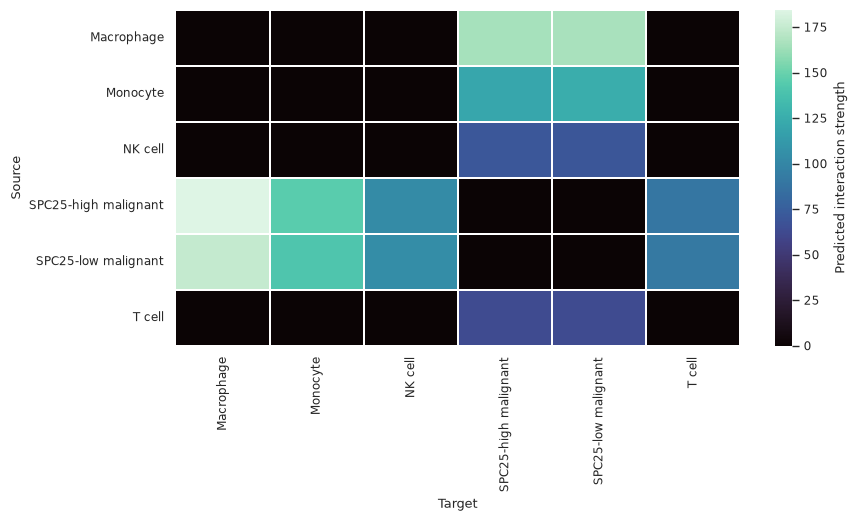

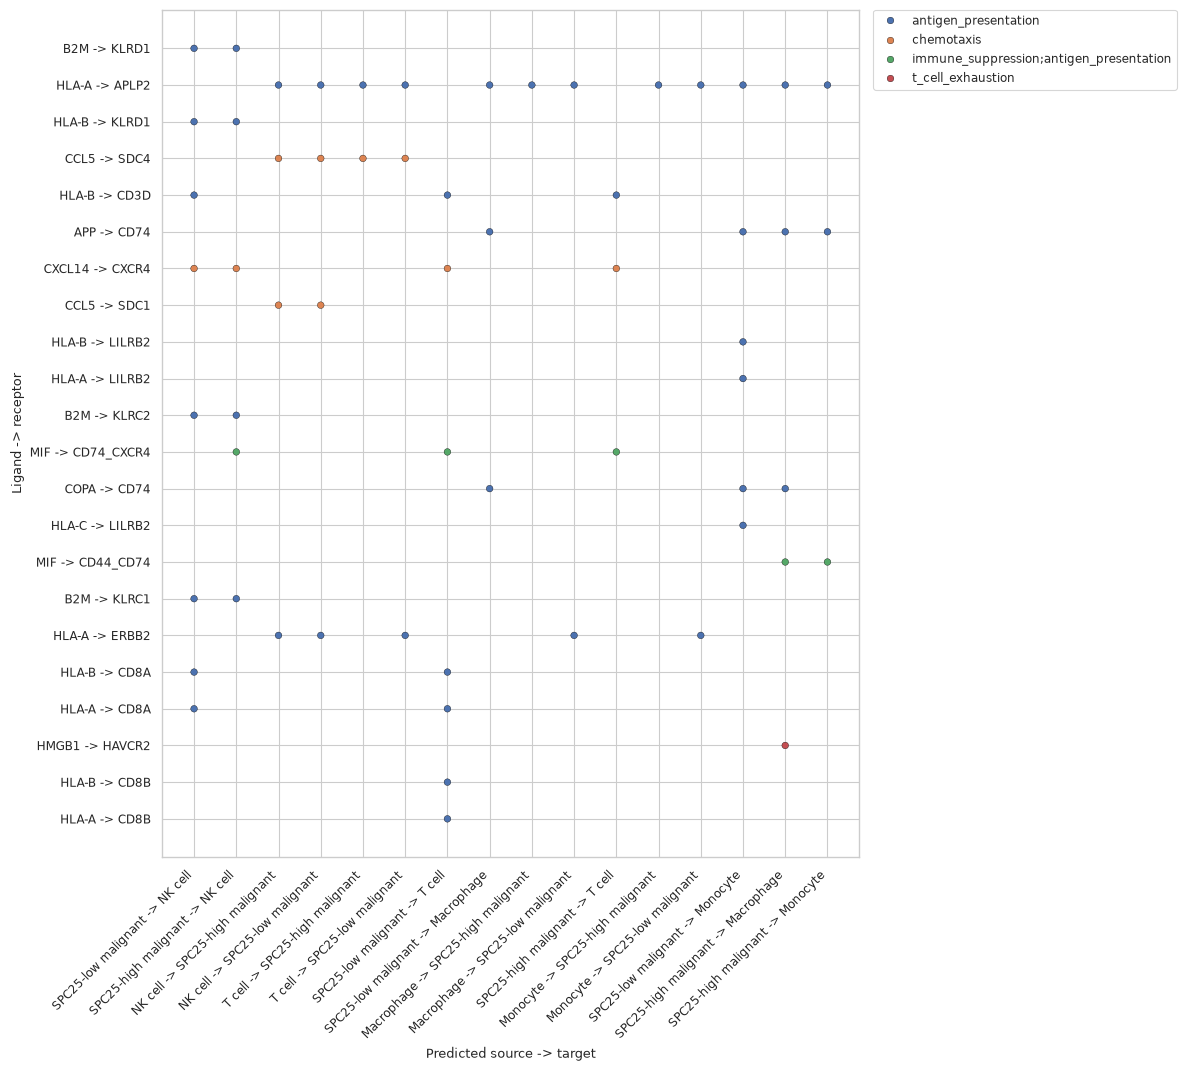

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper')

strength = pd.read_csv(OUT_DIR / 'liana_incoming_outgoing_strength.csv')
mat = strength.pivot(index='source', columns='target', values='sum_strength').fillna(0)
plt.figure(figsize=(1.0 * mat.shape[1] + 3, 0.55 * mat.shape[0] + 2))
sns.heatmap(mat, cmap='mako', linewidths=0.25, linecolor='white', cbar_kws={'label': 'Predicted interaction strength'})
plt.xlabel('Target')
plt.ylabel('Source')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liana_incoming_outgoing_strength_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'liana_incoming_outgoing_strength_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

focus = pd.read_csv(OUT_DIR / 'liana_focus_interactions.csv')
if len(focus) > 0:
    top_focus = focus.head(60).copy()
    ligand_col = 'ligand_complex' if 'ligand_complex' in top_focus.columns else 'ligand'
    receptor_col = 'receptor_complex' if 'receptor_complex' in top_focus.columns else 'receptor'
    top_focus['interaction'] = top_focus[ligand_col].astype(str) + ' -> ' + top_focus[receptor_col].astype(str)
    top_focus['pair'] = top_focus['source'].astype(str) + ' -> ' + top_focus['target'].astype(str)
    plt.figure(figsize=(12, max(5, 0.18 * len(top_focus))))
    sns.scatterplot(
        data=top_focus,
        x='pair', y='interaction',
        hue='focus_category', size='interaction_strength' if 'interaction_strength' in top_focus.columns else None,
        sizes=(20, 180), edgecolor='black', linewidth=0.25,
    )
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Predicted source -> target')
    plt.ylabel('Ligand -> receptor')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'liana_focus_interactions_dotplot.pdf', bbox_inches='tight')
    plt.savefig(FIG_DIR / 'liana_focus_interactions_dotplot.png', dpi=300, bbox_inches='tight')
    plt.show()

## Save run information

In [11]:
info = {
    'python': sys.version,
    'liana': li.__version__,
    'scanpy': sc.__version__,
    'full_h5ad': str(FULL_H5AD),
    'malignant_h5ad': str(MALIGNANT_H5AD),
    'group_col': GROUP_COL,
    'spc25_gene': GENE,
    'max_cells_per_group': MAX_CELLS_PER_GROUP,
    'expr_prop': EXPR_PROP,
    'min_cells': MIN_CELLS,
    'n_perms': N_PERMS,
}
(OUT_DIR / 'run_info.json').write_text(json.dumps(info, indent=2), encoding='utf-8')
print(json.dumps(info, indent=2))

{
  "python": "3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:34:02) [GCC 14.3.0]",
  "liana": "1.7.3",
  "scanpy": "1.11.5",
  "full_h5ad": "/data/work/2026317luad/GSE131907_GSE253013_allgenes_cnv.h5ad",
  "malignant_h5ad": "/data/work/2026317luad/GSE131907_GSE253013_mEpi_anno.h5ad",
  "group_col": "liana_group",
  "spc25_gene": "SPC25",
  "max_cells_per_group": 15000,
  "expr_prop": 0.1,
  "min_cells": 20,
  "n_perms": 1000
}
